In [15]:
import pandas as pd
import numpy as np

In [16]:
data = pd.read_csv('card_transdata.csv')
data.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


**EDA**

Now that the data is loaded, we can begin EDA

In [17]:
print("shape:",data.shape) #large dataset: 1,000,000 rows
data.info()


shape: (1000000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [18]:
#check for missing values
print(data.isna().values.any())
print(data.isnull().values.any())

False
False


This dataset contains no missing values.

Now, let's plot the target variable, which is 'fraud'. 'Fraud' is a categorical variable where an output of 0 means that the transaction was not fraudulent and an output of 1 means that it was. Let's find out what percentage of all transactions in this data
set were fraudulent.

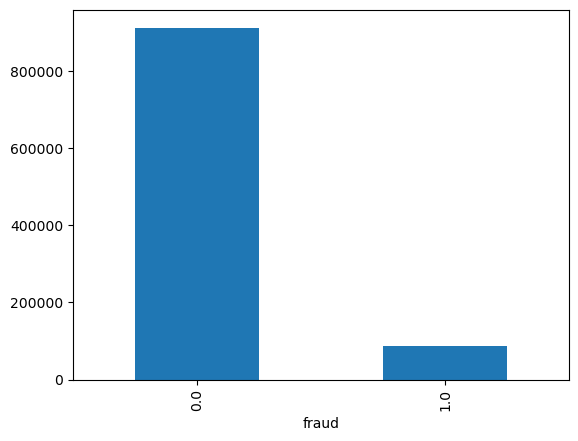

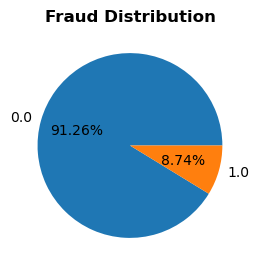

In [19]:
#TARGET VARIABLE
#bar plot
data['fraud'].value_counts().plot(kind='bar')

#pie plot

import matplotlib
from matplotlib import pylab as plt


#pie chart
plt.figure(figsize = (5, 3))
plt.pie(x = data['fraud'].value_counts().values,
        labels = data['fraud'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Fraud Distribution', size = 12, weight = 'bold')
plt.show()
#only 8.74% of all transactions are fraudulent


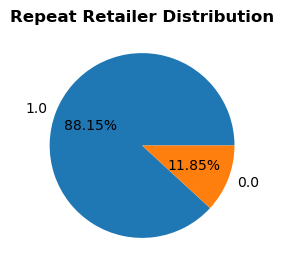

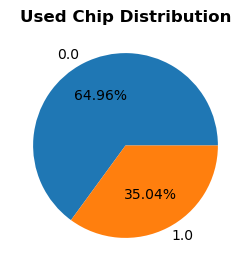

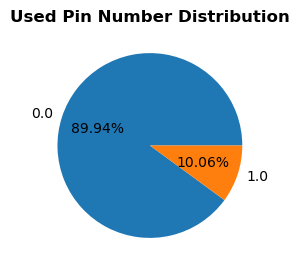

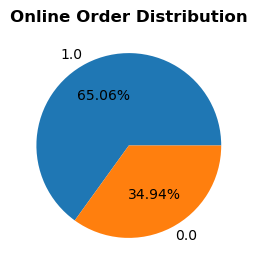

In [20]:
#Non-target categorical variables

plt.figure(figsize = (5, 3))
plt.pie(x = data['repeat_retailer'].value_counts().values,
        labels = data['repeat_retailer'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Repeat Retailer Distribution', size = 12, weight = 'bold')
plt.show()

plt.figure(figsize = (5, 3))
plt.pie(x = data['used_chip'].value_counts().values,
        labels = data['used_chip'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Used Chip Distribution', size = 12, weight = 'bold')
plt.show()

plt.figure(figsize = (5, 3))
plt.pie(x = data['used_pin_number'].value_counts().values,
        labels = data['used_pin_number'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Used Pin Number Distribution', size = 12, weight = 'bold')
plt.show()

plt.figure(figsize = (5, 3))
plt.pie(x = data['online_order'].value_counts().values,
        labels = data['online_order'].value_counts().index, 
        autopct = '%1.2f%%')
plt.title('Online Order Distribution', size = 12, weight = 'bold')
plt.show()

We can see that 8.74% of all transactions in our dataset were fraudulent.


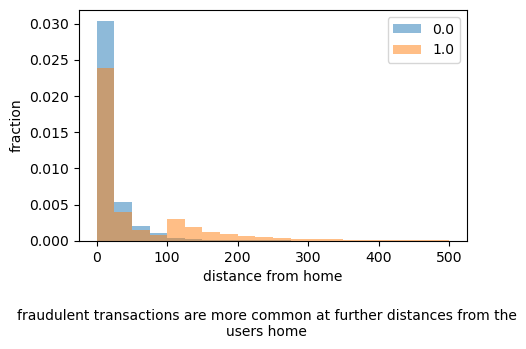

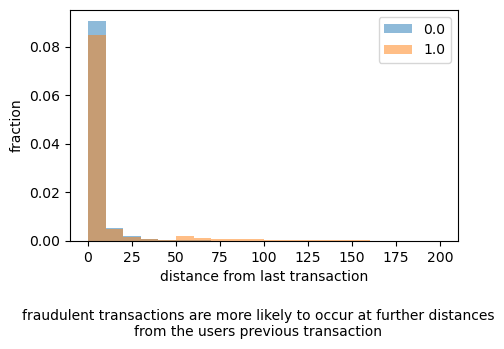

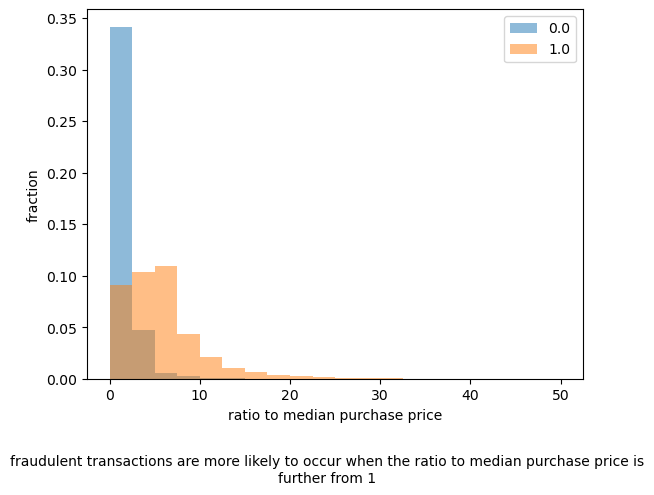

In [21]:
#histogram
#continuous to categorical: distance_from_home
categories = data['fraud'].unique()
bin_range = (data['distance_from_home'].min(), 500
            )

plt.figure(figsize=(5,3))

for c in categories:
    plt.hist(data[data['fraud']==c]['distance_from_home'],alpha=0.5,label=c,range=bin_range,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('distance from home')
caption = ('fraudulent transactions are more common at further distances from the users home')
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)
plt.show()


categories2 = data['fraud'].unique()
bin_range2 = (data['distance_from_home'].min(), 200
              
            )

plt.figure(figsize=(5,3))

for c in categories2:
    plt.hist(data[data['fraud']==c]['distance_from_last_transaction'],alpha=0.5,label=c,range=bin_range2,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('distance from last transaction')
caption = ('fraudulent transactions are more likely to occur at further distances from the users previous transaction')
plt.figtext(0.5, -0.2, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()


#RATIO
categories3= data['fraud'].unique()
bin_range2 = (data['ratio_to_median_purchase_price'].min(), 50
            )


for c in categories3:
    plt.hist(data[data['fraud']==c]['ratio_to_median_purchase_price'],alpha=0.5,label=c,range=bin_range2,bins=20,density=True)
plt.legend()
plt.ylabel('fraction')
plt.xlabel('ratio to median purchase price')
caption = ('fraudulent transactions are more likely to occur when the ratio to median purchase price is further from 1')
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()



<Axes: >

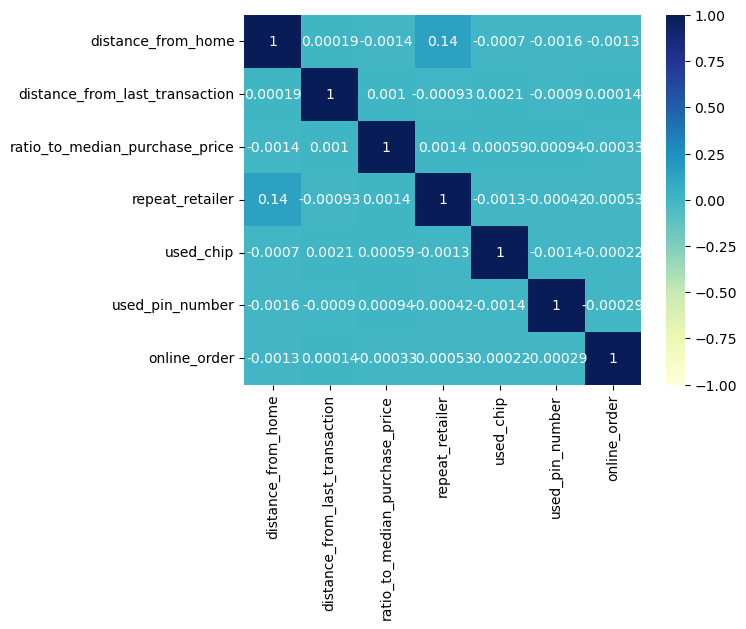

In [22]:
#check for correlated features
X = data.loc[:,data.columns != 'fraud']
y=data['fraud']

import seaborn as sns
corr_matrix = X.corr(method='pearson', min_periods=1, numeric_only=False) 

sns.heatmap(corr_matrix, vmin=-1, vmax=1, annot=True, cmap="YlGnBu")

We can see that none of the features are closely correlated, meaning we do not need to get rid of features to improve the convergence time of the model.

**Split Data**

Since this is a large dataset, 98% of data will be in the training set, 1% in the validation set, and 1% in the test set. The data is unbalanced, so I will be using a stratified k-fold approach to account for that. 

In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold

#identify feature matrix and target feature
X=data.loc[:,data.columns != 'fraud']
y=data['fraud']

#stratified train_test_split
random_state = 42

X_train, X_other, y_train, y_other = train_test_split(X,y,train_size = 0.98,stratify=y,random_state=random_state)
X_val, X_test, y_val, y_test = train_test_split(X_other,y_other,train_size = 0.5,stratify=y_other,random_state=random_state)
print('**balance with stratification:**')
print(np.unique(y_train,return_counts=True))
print(np.unique(y_val,return_counts=True))
print(np.unique(y_test,return_counts=True))


#Stratified kfold split on other
kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=random_state) 
for train_index, val_index in kf.split(X_other,y_other):
    print('new fold')
    X_train = X_other.iloc[train_index]
    y_train = y_other.iloc[train_index] 
    X_val = X_other.iloc[val_index]
    y_val = y_other.iloc[val_index]
    print(np.unique(y_train,return_counts=True))
    print(np.unique(y_val,return_counts=True))

#test outputs and check for reproducibility
print("X train:",X_train.shape)
print("X test:",X_test.shape)
print("X val:",X_val.shape)
print("Y val:", y_val.shape[0])

**balance with stratification:**
(array([0., 1.]), array([894345,  85655]))
(array([0., 1.]), array([9126,  874]))
(array([0., 1.]), array([9126,  874]))
new fold
(array([0., 1.]), array([14601,  1399]))
(array([0., 1.]), array([3651,  349]))
new fold
(array([0., 1.]), array([14601,  1399]))
(array([0., 1.]), array([3651,  349]))
new fold
(array([0., 1.]), array([14602,  1398]))
(array([0., 1.]), array([3650,  350]))
new fold
(array([0., 1.]), array([14602,  1398]))
(array([0., 1.]), array([3650,  350]))
new fold
(array([0., 1.]), array([14602,  1398]))
(array([0., 1.]), array([3650,  350]))
X train: (16000, 7)
X test: (10000, 7)
X val: (4000, 7)
Y val: 4000


In [24]:
print(y.value_counts())

fraud
0.0    912597
1.0     87403
Name: count, dtype: int64


**Preprocessing**

Categorical features: repeat_retailer, used_chip, used_pin_number, online_order
Continuous features: distance_from_home, distance_from_last_transaction, ratio_to_median_purchase_price

The continuous features all follow a tail distribution so I will preprocess them using StandardScaler.
I'll use OneHotEncoder to preprocess the categorical variables. Even though they don't necessarily need to be preprocessed since they are already zeroes and ones and there are no missing values, I will run OneHotEncoder so I don't have to re-append the columns to my preprocoessed data.


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


cat_ftrs = ['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']
ftrs = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

preprocessor = ColumnTransformer(
   transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown= 'ignore'), cat_ftrs),
        ('std', StandardScaler(), ftrs)])


clf = Pipeline(steps=[('preprocessor', preprocessor)])

X_train_prep = clf.fit_transform(X_train)
X_val_prep = clf.fit_transform(X_val)
X_test_prep = clf.fit_transform(X_test)

print("X train shape", X_train.shape)
print("X train prep shape", X_train_prep.shape)
print(X_train_prep)


#initialize the encoder
enc = OneHotEncoder(sparse_output=False,handle_unknown='ignore')
# fit encoder
enc.fit(X_train[cat_ftrs])
# transform X_train
onehot_train = enc.transform(X_train[cat_ftrs])
print('transformed train features:')
print(onehot_train)
# transform X_val
onehot_val = enc.transform(X_val[cat_ftrs])
print('transformed val features:')
print(onehot_val) and I 
# transform X_test
onehot_test = enc.transform(X_test[cat_ftrs])
print('transformed test features:')
print(onehot_test)


X train shape (16000, 7)
X train prep shape (16000, 11)
[[ 0.          1.          0.         ... -0.38768962 -0.19270526
  -0.56291963]
 [ 0.          1.          1.         ...  0.55757417  0.65053278
  -0.52640449]
 [ 0.          1.          0.         ...  8.59965022 -0.23529933
   5.03544442]
 ...
 [ 0.          1.          1.         ... -0.36267725 -0.15450763
  -0.57574214]
 [ 0.          1.          1.         ...  0.1423172   0.77156549
  -0.18696424]
 [ 0.          1.          1.         ... -0.33115875 -0.23676512
   0.52712975]]
transformed train features:
[[0. 1. 0. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 1.]
 ...
 [0. 1. 1. ... 0. 1. 0.]
 [0. 1. 1. ... 0. 0. 1.]
 [0. 1. 1. ... 0. 1. 0.]]
transformed val features:
[[1. 0. 1. ... 1. 0. 1.]
 [0. 1. 0. ... 0. 1. 0.]
 [0. 1. 1. ... 0. 1. 0.]
 ...
 [1. 0. 1. ... 0. 0. 1.]
 [1. 0. 1. ... 1. 0. 1.]
 [0. 1. 1. ... 0. 1. 0.]]
transformed test features:
[[0. 1. 0. ... 1. 0. 1.]
 [1. 0. 1. ... 0. 1. 0.]
 [0. 1. 1